# Example usage

Here we will demonstrate how to use `overviewpy` in a project:

## Import libraries

In [9]:
from overviewpy.overviewpy import Overview
import pandas as pd
import numpy as np

### Generate data

In the first step, we will generate some data that we will use in the next steps.

In [10]:
# Generate full data

data = {
        'id': ['RWA', 'RWA', 'RWA', 'GAB', 'GAB', 'FRA', 'FRA', 'BEL', 'BEL', 'ARG'],
        'year': [2022, 2023, 2021, 2023, 2020, 2019, 2015, 2014, 2013, 2002]
    }

df = pd.DataFrame(data)

df.head()

,id,year
0,RWA,2022
1,RWA,2023
2,RWA,2021
3,GAB,2023
4,GAB,2020


In [11]:
# Generate data with missing values

data_na = {
        'id': ['RWA', 'RWA', 'RWA', np.nan, 'GAB', 'GAB', 'FRA', 'FRA', 'BEL', 'BEL', 'ARG', np.nan,  np.nan],
        'year': [2022, 2001, 2000, 2023, 2021, 2023, 2020, 2019,  np.nan, 2015, 2014, 2013, 2002]
    }

df_na = pd.DataFrame(data_na)

### Get an overview of the time distribution in your data

Generate some general overview of the data set using the time and scope conditions with `overview_tab`. The resulting data frame collapses the time condition for each id by taking into account potential gaps in the time frame.


In [12]:
overview = Overview(df=df, id='id', time='year')
df_overview = overview.overview_tab()

print(df_overview)

    id  time_frame
9  ARG        2002
7  BEL   2013-2014
5  FRA  2015, 2019
3  GAB  2020, 2023
0  RWA   2021-2023


### Get an overview of missing data in your data frame

`overview_na` is a method that provides information about the content of all variables in your data, not only the time and scope conditions. It returns a horizontal ggplot bar plot that indicates the amount of missing data (NAs) for each variable (on the y-axis). You can choose whether to display the relative amount of NAs for each variable in percentage (the default) or the total number of NAs.

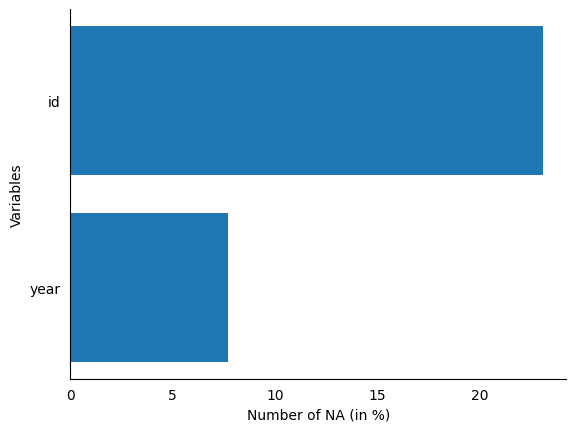

<Axes: xlabel='Number of NA (in %)', ylabel='Variables'>

In [13]:
overview_na = Overview(df=df_na, id='id', time='year')
overview_na.overview_na()

In [15]:
overview_na.overview_summary()

,non_null_count,unique_count,sample_values
column,,,
id,10,5,"[RWA, GAB, FRA, BEL, ARG]"
year,12,11,"[2022.0, 2001.0, 2000.0, 2023.0, 2021.0]"
